# Answers

You can edit this Jupyter notebook to include your answers and run any code that generates those answers or produces plots.  You can add additional cells for code or markdown as needed.

This homework is primarily about running simulations involving initial value problems (IVPs) and a simple PDE.

In [2]:
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
from scipy.integrate import DenseOutput
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
import scipy.sparse as sparse
import sympy as sp
from sympy import Function, dsolve, Eq, Derivative, sin, cos, symbols
from scipy.integrate import solve_ivp
import importlib

## Problem 0 (30 points)

In this problem, you will implement a custom ODE solver for `solve_ivp` based on the Forward Euler method, and implement some basic tests.

### Part A (20 points)
If you read the [documentation for `solve_ipv`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html), which we used in class, you'll see that you can write your own solver.

Write a solver for the forward Euler method, which is not implemented as one of the available solvers (while simple, it typically is not very accurate).  Recall, this is the basic rule:
\begin{equation}
y(t + h) = y(t) + h f(t, y)
\end{equation}

Your solver should be a class which is derived from [`scipy.integrate.OdeSolver`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.OdeSolver.html#scipy.integrate.OdeSolver)
```python
class ForwardEuler(scipy.integrate.OdeSolver):
    pass
```

Your class definition should go in [`euler.py`](euler.py)

You should read the documentation for this base class in order to implement `ForwardEuler`.  Here are some hints/notes:
* Allow a user to set `h` using a keyword argument.  This can be passed using `solve_ivp(..., method=ForwardEuler, h=0.01)` to set `h=0.01`
* Use a default step size `h = (t_bound - t0) / 100`
* private methods begin with an underscore "_"
* the method `_dense_output_impl(self)` should output a `ForwardEulerOutput` (defined in [`euler.py`](euler.py))
* direction should be `+1`
* You won't use a Jacobian, so `njev` and `nlu` can remain at 0.
* You may want to consider using `super(ForwardEuler, self).__init__`
* You may want to read the source code for the parent class [here](https://github.com/scipy/scipy/blob/v1.5.3/scipy/integrate/_ivp/base.py#L25-L214)

---

*put any discussion here*

In [4]:
from euler import ForwardEuler
from sympy.abc import x # x is overwritten in previous cells so we need to import here

### Part B (10 points)

Use your `ForwardEuler` solver and `solve_ivp` to solve an IVP $y'(t) = y$ with $y(0) = 1$ on the domain $t\in [0,5]$, using a step size `h=0.01`.  Make a plot of the solution to this IVP with axes labeled `y` and `x`.

Use SymPy to obtain the ground-truth solution to this IVP.  What is the largest error you see on the domain you solved the problem?  Try solving with the default solver in `solve_ivp`.  What is the largest error in this case?

---

*put your answers here*

Maximum error with Forward Euler: 3.640387
Maximum error with default solver: 0.018750


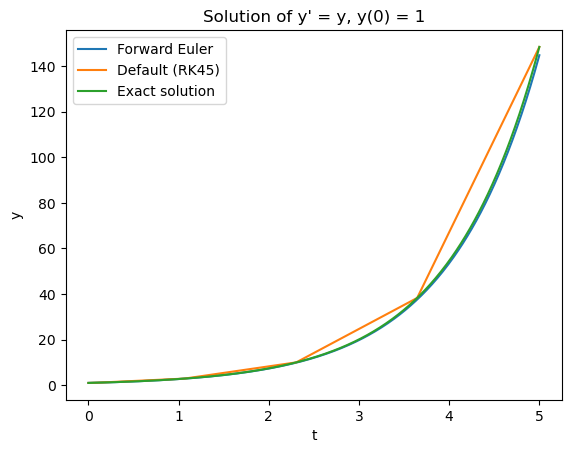

In [6]:
import sympy as sp

# Define the ODE: y' = y
def ode(t, y):
    return y

sol_euler = solve_ivp(ode, (0, 5), [1.0], method=ForwardEuler, h=0.01)
sol_default = solve_ivp(ode, (0, 5), [1.0], method='RK45')

# Get exact solution using SymPy
t_symbol = sp.symbols('t')
y_symbol = sp.Function('y')(t_symbol)
ode_eq = sp.Eq(y_symbol.diff(t_symbol), y_symbol)
initial_condition = {y_symbol.subs(t_symbol, 0): 1}
exact_sol = sp.dsolve(ode_eq, y_symbol, ics=initial_condition)
exact_func = sp.lambdify(t_symbol, exact_sol.rhs, 'numpy')

# Calculate exact values at our time points
t_exact = sol_euler.t
y_exact = exact_func(t_exact)

# Calculate errors
error_euler = np.abs(sol_euler.y[0] - y_exact)
error_default = np.abs(sol_default.y[0] - exact_func(sol_default.t))

print(f"Maximum error with Forward Euler: {np.max(error_euler):.6f}")
print(f"Maximum error with default solver: {np.max(error_default):.6f}")

# Plot the results
plt.plot(sol_euler.t, sol_euler.y[0], label='Forward Euler')
plt.plot(sol_default.t, sol_default.y[0], label='Default (RK45)')
plt.plot(t_exact, y_exact, label='Exact solution')
plt.xlabel('t')
plt.ylabel('y')
plt.title("Solution of y' = y, y(0) = 1")
plt.legend()
plt.show()

### Part C (optional challenge)

Use Richardson (see Problem 0) on your Forward Euler solver. How does the error change? You can assume that $m=1$ and derive the formula analytically. What happens if you do Richardson twice?

## Problem 1 (20 points)

Now that you're warmed up, here are some more simulations.

### Part A (15 points)

In this problem, we'll simulate a planet and moon moving in a 2-dimensional plane.

Newton's law of gravity says that $F_g = Gm_1 m_2 / \|r\|^2$.  The direction of the force is in the direction of the vector $r$.  Let $x(t)$ dentote the position of the planet and $y(t)$ denote the position of the moon, and $r(t) = x(t) - y(t)$ Then
\begin{equation}
x''(t) = -F_g / m_1 \times r / \|r\|\\
y''(t) = F_g / m_2 \times r / \|r\|
\end{equation}
$x$ and $y$ are 2-vectors, so this is a system of 4-second order ODEs.  We can use the following trick to write this as 8 first order ODEs. Let $p(t)$ be the velocity of the planet and $q(t)$ be the velocity of the moon (note that they are vector valued!). So, $p(t) = x'(t)$, and $q(t) = y'(t)$.  Here are the terms for $x$:
\begin{equation}
p_1'(t) = -F_g / m_1 \times r_1(t) / \|r\|\\
p_2'(t) = -F_g / m_1 \times r_2(t) / \|r\|\\
x_1'(t) = p_1(t)\\
x_2'(t) = p_2(t)
\end{equation}
\begin{equation}
q_1'(t) = F_g / m_2 \times r_1(t) / \|r\|\\
q_2'(t) = F_g / m_2 \times r_2(t) / \|r\|\\
y_1'(t) = q_1(t)\\
y_2'(t) = q_2(t)
\end{equation}

We'll model the Earth and moon.  The [Gravitational constant](https://en.wikipedia.org/wiki/Gravitational_constant) has value `G=6.67 e-11` (we're dropping units, which are all SI).  The mass of the earth is `m1 = 5.972 e24`, and the mass of the moon is `m2=0.07346 e24`.  The distance from the moon to the earth is `r = 384.4 e6`.  This means the orbital speed of the moon around the earth is about `1.022 e3`.

Use `solve_ivp` to run a simulation of the moon orbiting the earth for `5 e6` seconds (about 2 months).  Use initial conditions $x(0) = 0, p(0) = 0$ for the earth, and $y(0) = (0, 384.4 \times 10^6)$ and $q(0) = (1.022 \times 10^3, 0)$

Plot $x_1(t), x_2(t)$ and $y_1(t), y_2(t)$ in the same plane with different colors (include a legend and title).

---

*Put any answers/discussion here*

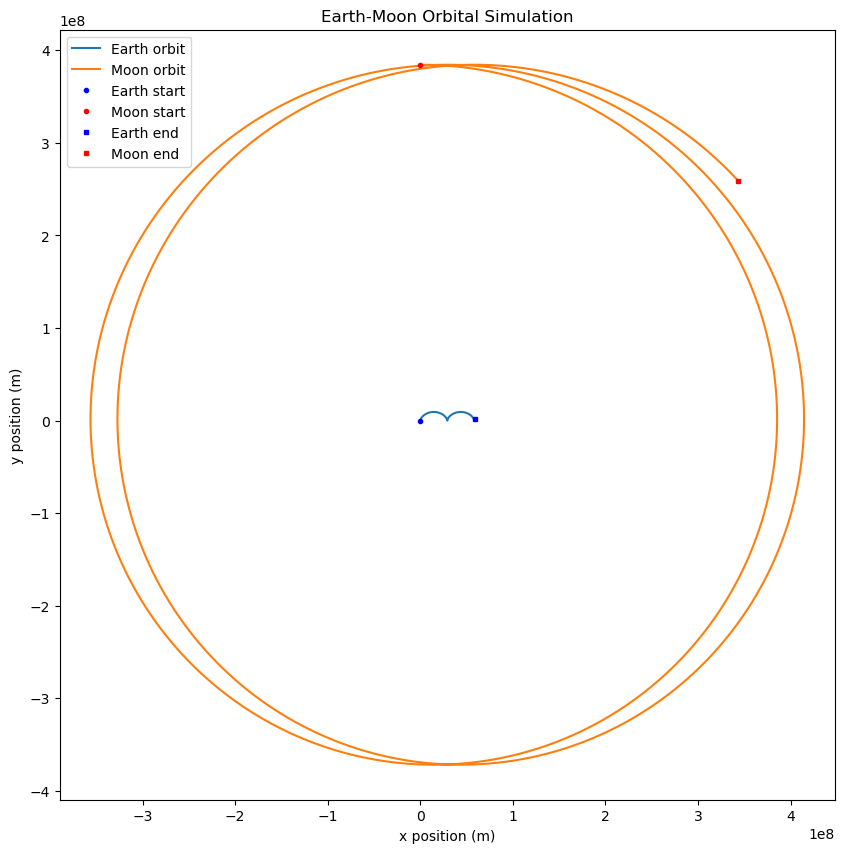

In [9]:
# Constants
G = 6.67e-11
m1 = 5.972e24 # Earth
m2 = 0.07346e24 # Moon
r = 384.4e6
v_moon = 1.022e3

# Initial conditions
# Earth: position (0,0), velocity (0,0)
# Moon: position (0, r), velocity (v_moon, 0)
initial_state = [0, 0, 0, 0, 0, r, v_moon, 0]

def gravitation_ode(t, state):
    """
    System of ODEs for Earth-Moon gravitational interaction
    state = [x1, x2, p1, p2, y1, y2, q1, q2]
    where:
        x1, x2: Earth position coordinates
        p1, p2: Earth velocity components  
        y1, y2: Moon position coordinates
        q1, q2: Moon velocity components
    """
    x1, x2, p1, p2, y1, y2, q1, q2 = state
    
    # Position vector from Earth to Moon
    r_vec = np.array([x1 - y1, x2 - y2])
    r_mag = np.linalg.norm(r_vec)
    
    # Force magnitude
    F_g = G * m1 * m2 / (r_mag**2)
    
    # Unit vector in direction of r
    r_unit = r_vec / r_mag
    
    # Derivatives for Earth
    dp1_dt = -F_g / m1 * r_unit[0]
    dp2_dt = -F_g / m1 * r_unit[1]
    dx1_dt = p1
    dx2_dt = p2
    
    # Derivatives for Moon  
    dq1_dt = F_g / m2 * r_unit[0]
    dq2_dt = F_g / m2 * r_unit[1]
    dy1_dt = q1
    dy2_dt = q2
    
    return [dx1_dt, dx2_dt, dp1_dt, dp2_dt, dy1_dt, dy2_dt, dq1_dt, dq2_dt]

# Time span
t_span = (0, 5e6)
t_eval = np.linspace(0, 5e6, 5000)  # Evaluation points

# Solve ODE
solution = solve_ivp(gravitation_ode, t_span, initial_state, method='RK45', t_eval=t_eval, rtol=1e-8, atol=1e-11)

# Extract positions
earth_x = solution.y[0]  # Earth x-position
earth_y = solution.y[1]  # Earth y-position  
moon_x = solution.y[4]   # Moon x-position
moon_y = solution.y[5]   # Moon y-position

plt.figure(figsize=(10, 10))
plt.plot(earth_x, earth_y, label='Earth orbit')
plt.plot(moon_x, moon_y, label='Moon orbit')
plt.plot(earth_x[0], earth_y[0], 'bo', markersize=3, label='Earth start')
plt.plot(moon_x[0], moon_y[0], 'ro', markersize=3, label='Moon start')
plt.plot(earth_x[-1], earth_y[-1], 'bs', markersize=3, label='Earth end')
plt.plot(moon_x[-1], moon_y[-1], 'rs', markersize=3, label='Moon end')

plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.title('Earth-Moon Orbital Simulation')
plt.legend()
plt.axis('equal')
plt.show()

### Part B (5 points)

Now simulate a system with 10 planets, in 10 random locations. The planets should have random masses chosen independently and uniformly from the interval $[0,6 \times 10^{24}]$ and initial locations chosen randomly from the $(8 \times 10^8) \times (8\times 10^8)$ square centered at the origin. The components of each planet's initial velocity should be chosen randomly on $[-5\times 10^{2}, 5 \times 10^{2}].$ Plot the positions of each planet as a function of time.

---

*Your answer here.  You can create some code cells as well*

In [11]:
np.random.seed(1)

# Constants
G = 6.67e-11

def n_body_gravitation_ode(t, state, masses, n_bodies):

    # Reshape state to (n_bodies, 4) where each row is [x, y, vx, vy]
    positions_velocities = state.reshape(n_bodies, 4)
    positions = positions_velocities[:, :2]  # (n_bodies, 2)
    velocities = positions_velocities[:, 2:]  # (n_bodies, 2)
    
    # Initialize derivatives
    dxdt = np.zeros_like(positions)
    dvdt = np.zeros_like(velocities)
    
    # For each body, calculate acceleration due to all other bodies
    for i in range(n_bodies):
        dxdt[i] = velocities[i]  # Position derivative is velocity
        
        total_acceleration = np.zeros(2)
        for j in range(n_bodies):
            if i != j:  # exclude self
                r_vec = positions[j] - positions[i]
                r_mag = np.linalg.norm(r_vec)
                
                # Avoid division by zero with small epsilon
                if r_mag < 1e6:  # If bodies are too close, limit force
                    r_mag = 1e6
                
                # Gravitational acceleration
                acceleration = G * masses[j] / (r_mag**3) * r_vec
                total_acceleration += acceleration
        
        dvdt[i] = total_acceleration
    
    # Flatten back to 1D array
    return np.hstack([dxdt, dvdt]).flatten()

# Parameters
n_planets = 10
simulation_time = 5e5

# Mass
masses = np.random.uniform(0, 6e24, n_planets)

# Initial Positon
positions = np.random.uniform(-4e8, 4e8, (n_planets, 2))

# Initial Velocity
velocities = np.random.uniform(-500, 500, (n_planets, 2))

# Combine into initial state vector
initial_state = np.hstack([positions, velocities]).flatten()

# Time points
t_eval = np.linspace(0, simulation_time, 500)

# Solve ODE
solution = solve_ivp(n_body_gravitation_ode, (0, simulation_time), initial_state,
                     args=(masses, n_planets), method='RK45', t_eval=t_eval,
                     rtol=1e-8, atol=1e-11)

# Extract and reshape the solution
trajectories = solution.y.reshape(n_planets, 4, -1)  # Shape: (n_planets, 4, time_steps)

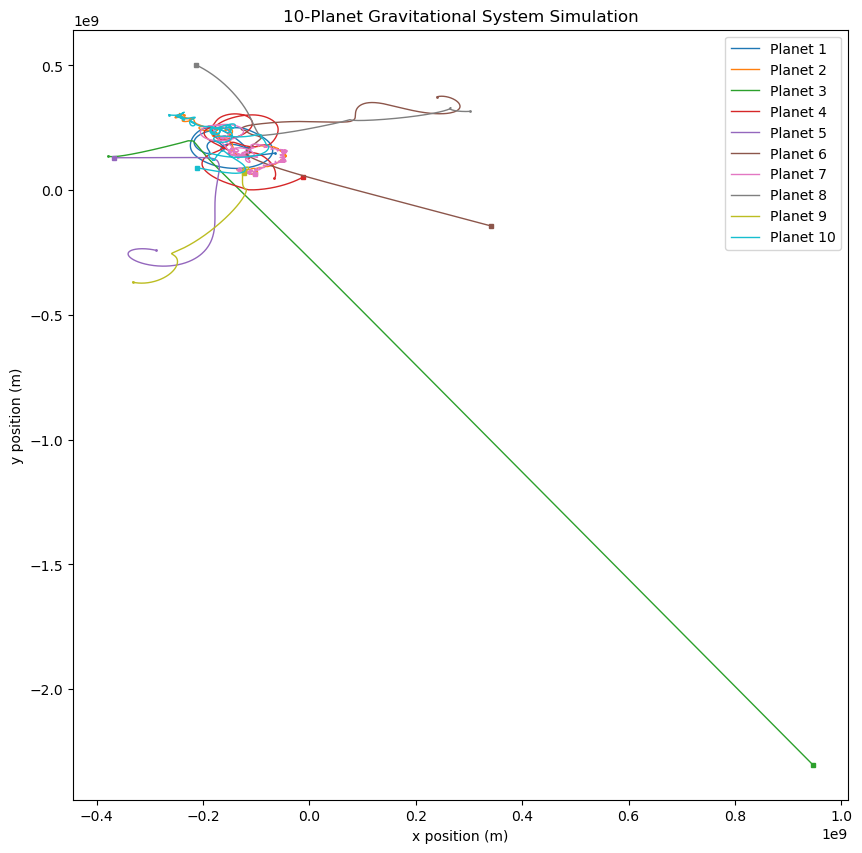

In [12]:
plt.figure(figsize=(10, 10))

# Plot each planet's trajectory with a different color
colors = plt.cm.tab10(np.linspace(0, 1, n_planets))

for i in range(n_planets):
    x_pos = trajectories[i, 0, :]
    y_pos = trajectories[i, 1, :]
    
    # Plot trajectory
    plt.plot(x_pos, y_pos, color=colors[i], linewidth=1, label=f'Planet {i+1}')
    
    # Mark start and end points
    plt.plot(x_pos[0], y_pos[0], 'o', color=colors[i], markersize=1)
    plt.plot(x_pos[-1], y_pos[-1], 's', color=colors[i], markersize=3)

plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.title(f'10-Planet Gravitational System Simulation')
plt.legend()
plt.show()

## Problem 2 (30 points)
In this problem, we will solve some a simple PDE using the "method of lines". In this method, we replace the
$$\partial_t u(t,x) = \Delta u(t,x) $$
PDE by the system of ODEs
$$ \partial_t\boldsymbol{u}(t) = A \boldsymbol{u}(t),$$
where
$$[\boldsymbol{u}(t)]_i=u_i(t) \approx u(t,x_i). $$
The matrix $A$ approximates the differential operator using, e.g. finite differences
$$ \Delta u \to A \boldsymbol{u}.$$

After we semi-discretize in space we are left with a large system of ODEs that we can solve using our favorite method.
 

### Part A (25 points)
In this problem we will solve the heat equation 
\begin{equation}
\begin{cases}
\partial_t u(t,x) = \Delta u(t,x) & x\in [0,1], \;t\in[0,T]\\
u(0,x) = f(x) & x\in [0,1]\\
u(t,0) = a & t \in [0,T]\\
u(t,1) = b & t \in [0,T]\\
\end{cases}
\end{equation}
with the method of lines.

To solve this equation, we discretize the interval $x\in[0,1]$ with $n+2$ points. The end points will be used to enforce boundary conditions and the interior points will be used to compute the right hand side of the PDE. We approximate the Laplacian operator using the second order centered difference formula
$$g''(x) = \frac{g(x+h)-2g(x)+g(x-h)}{h^2}$$
and we integrate in time using the forward Euler method.

Your code for implementing this method should include the following three functions
1. `second_diff`, which computes the second derivative of $u$ at the interior nodes (using the centered difference formula) and returns it as an array with zeros on each end (as the boundary conditions don't change)
2. `forward_time_step`, which uses $u(t_n,x)$ and the forward Euler method to compute $u(t_{n+1},x)$
3. `sim_heat`, which solves the heat equation by setting $u(0,x)=f(x)$ and then calling `forward_time_step` repeatedly to compute $u(T,x)$. This function should accept the following inputes
    * `n` the number of internal nodes 
    * `f` the initial condition
    * `bc` a list containing the left and right boundary conditions $a$ and $b$
    * `dx` the grid spacing, i.e. the distance between x values i.e. $1/(n+1)$
    * `dt` the time step to be used by the forward Euler method
    * `T` the time at which we want the solution $u(T,x)$. Note that in general $T/dt$ will not be an integer, so the last call of `forward_time_step` will have to use a smaller time step than `dt`

Once you have created these functions, solve the heat equation with
\begin{gather}
f(x) = \sin(2\pi x)\\
a = b = 0
\end{gather}
up until time $T=0.02$ using $n=99$ and `dt=0.2*dx**2`. 

To verify the accuracy of your code, compare the output to the exact solution $u(t,x)= \exp(-4\pi^2t)\sin(2\pi x)$. You can do this by summing the sum of squares errors at your $x_i$'s and dividing by $\sqrt{n}$.

You should also include a plot of $u(0,x)$ and $u(T,x)$.

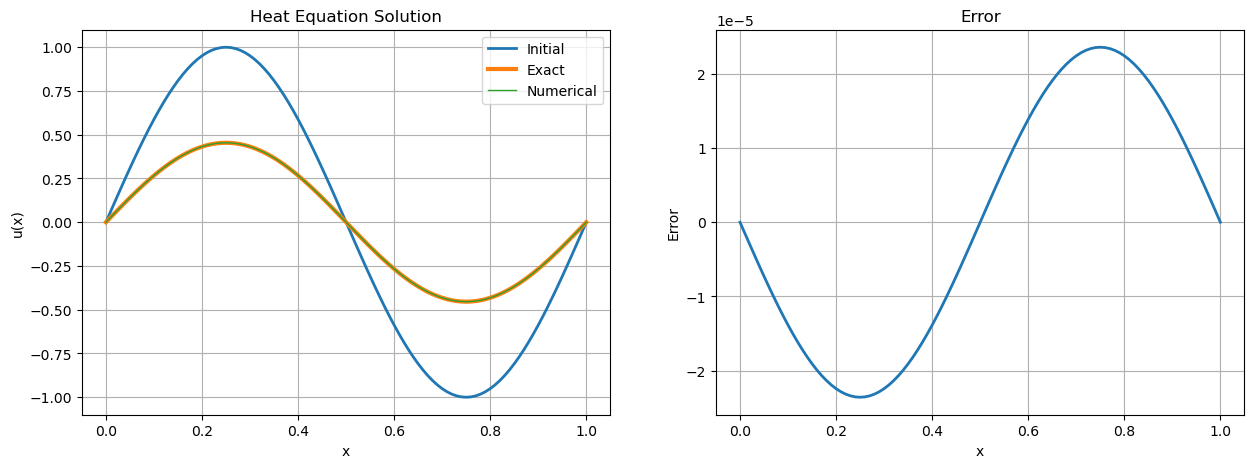

Error (sum_of_squares / sqrt(n)): 2.795127e-09


In [15]:
def second_diff(u, dx):
    """
    Compute the second derivative using centered finite differences.
    
    Parameters:
    u: array of function values at grid points (including boundaries)
    dx: grid spacing
    
    Returns:
    d2u: second derivative at interior points, with zeros at boundaries
    """
    n = len(u) - 2  # number of interior points
    d2u = np.zeros_like(u)
    
    # Second derivative at interior points using centered difference
    for i in range(1, n+1):
        d2u[i] = (u[i+1] - 2*u[i] + u[i-1]) / (dx**2)
    
    return d2u

def forward_time_step(u, dx, dt, bc):
    """
    Perform one forward Euler time step for the heat equation.
    
    Parameters:
    u: current solution (including boundaries)
    dx: grid spacing
    dt: time step
    bc: boundary conditions [a, b]
    
    Returns:
    u_new: solution at next time step
    """
    # Compute second derivative
    d2u = second_diff(u, dx)
    
    # Forward Euler update
    u_new = u + dt * d2u
    
    # Apply boundary conditions
    u_new[0] = bc[0]  # left boundary
    u_new[-1] = bc[1]  # right boundary
    
    return u_new

def sim_heat(n, f, bc, dx, dt, T):
    """
    Solve the heat equation using method of lines with forward Euler.
    
    Parameters:
    n: number of interior points
    f: initial condition function
    bc: boundary conditions [a, b]
    dx: grid spacing
    dt: time step
    T: final time
    
    Returns:
    u_final: solution at time T
    x: spatial grid
    """
    # Total points including boundaries
    total_points = n + 2
    
    # Spatial grid
    x = np.linspace(0, 1, total_points)
    
    # Initial condition
    u = f(x)
    
    # Apply boundary conditions to initial condition
    u[0] = bc[0]
    u[-1] = bc[1]
    
    # Time stepping
    current_time = 0
    while current_time < T:
        # Adjust dt for final step if needed
        step_dt = min(dt, T - current_time)
        
        # Perform time step
        u = forward_time_step(u, dx, step_dt, bc)
        current_time += step_dt
    
    return u, x

# Parameters
n = 99
dx = 1.0 / (n + 1)  # grid spacing
dt = 0.2 * dx**2    # time step (CFL condition)
T = 0.02            # final time

# Initial condition and boundary conditions
def f(x):
    return np.sin(2 * np.pi * x)

bc = [0, 0]  # boundary conditions a = 0, b = 0

u_numerical, x = sim_heat(n, f, bc, dx, dt, T)

# Exact solution
def exact_solution(t, x):
    return np.exp(-4 * np.pi**2 * t) * np.sin(2 * np.pi * x)

u_exact = exact_solution(T, x)

plt.figure(figsize=(15, 5))

# Initial and final solutions
plt.subplot(1, 2, 1)
u_initial = f(x)
plt.plot(x, u_initial, linewidth=2, label='Initial')
plt.plot(x, u_exact, linewidth=3, label=f'Exact')
plt.plot(x, u_numerical, linewidth=1, label=f'Numerical')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Heat Equation Solution')
plt.legend()
plt.grid()

# Error
plt.subplot(1, 2, 2)
error_plot = u_numerical - u_exact
plt.plot(x, error_plot, linewidth=2)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Error')
plt.grid()

plt.show()

error = np.sum((u_numerical - u_exact)**2) / np.sqrt(n)
print(f"Error (sum_of_squares / sqrt(n)): {error:.6e}")

## Part B (5 points)
Now solve for $u(T,x)$ using the same parameters as above, except that you should set `dt=0.7*dx**2`. Create a plot of $u(0,x)$ and $u(T,x)$ and compare it to the plot from the previous question. The ratio $dt/dx^2$ is called the CFL (Courant–Friedrichs–Lewy) number and the observation that you will make is an important concept in numerical PDE methods.

Error (sum_of_squares / sqrt(n)): 3.481628e+113


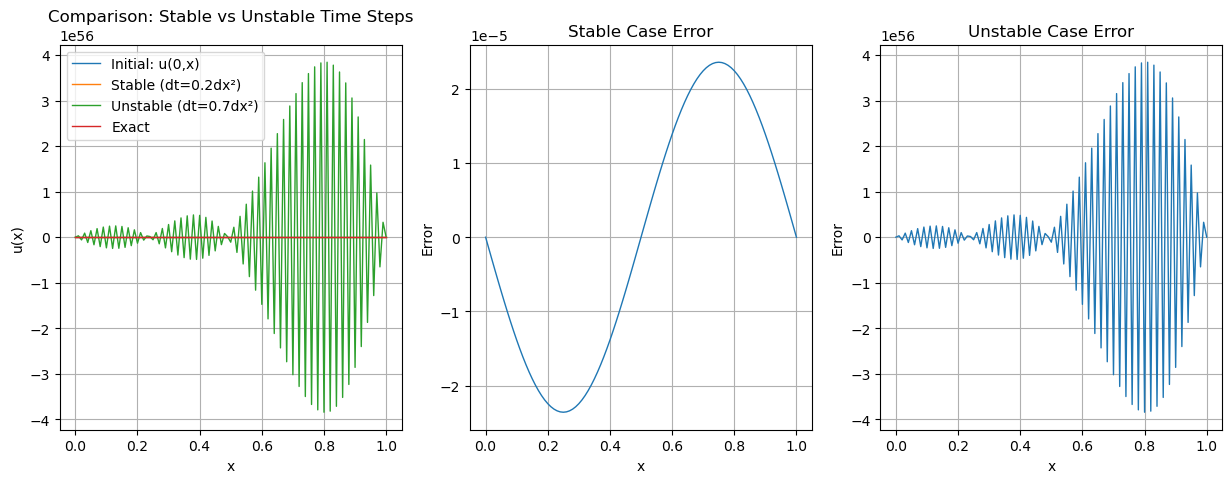

In [17]:
# Parameters
dt = 0.7 * dx**2

u_numerical_b, x = sim_heat(n, f, bc, dx, dt, T)

error_b = np.sum((u_numerical_b - u_exact)**2) / np.sqrt(n)

print(f"Error (sum_of_squares / sqrt(n)): {error_b:.6e}")

# Plot comparison between stable and unstable cases
plt.figure(figsize=(15, 5))

# Recompute the stable solution for comparison
dt_stable = 0.2 * dx**2
u_numerical_stable, _ = sim_heat(n, f, bc, dx, dt_stable, T)

# solutions
plt.subplot(1, 3, 1)
u_initial = f(x)
plt.plot(x, u_initial, linewidth=1, label='Initial: u(0,x)')
plt.plot(x, u_numerical_stable, linewidth=1, label=f'Stable (dt=0.2dx²)')
plt.plot(x, u_numerical_b, linewidth=1, label=f'Unstable (dt=0.7dx²)')
plt.plot(x, u_exact, linewidth=1, label='Exact')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Comparison: Stable vs Unstable Time Steps')
plt.legend()
plt.grid()

# Error stable
plt.subplot(1, 3, 2)
error_stable = u_numerical_stable - u_exact
plt.plot(x, error_stable, linewidth=1)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Stable Case Error')
plt.grid()

# Error unstable
plt.subplot(1, 3, 3)
error_unstable = u_numerical_b - u_exact
plt.plot(x, error_unstable, linewidth=1)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Unstable Case Error')
plt.grid()

plt.show()

## Part C (optional, 5 bonus points)
The CFL condition that $dt/dx^2<0.5$ is prohibitively restrictive. To get around this, we can use so-called implicit time stepping schemes, which are far more stable, though computationally costly. The simplest of these schemes is the backwards Euler method:
$$ y(t_{n+1}) = y(t_n) + dt y'(t_{n+1})$$
(Note that $y'$ is now evaluated at a future time.) When solving a linear system of ODEs
$$ y'= A y$$
the backwards Euler method requires us to solve the linear system
$$ (I - dt A)y(t_{n+1}) = y(t_{n}). $$

In this problem you should modify your existing code to solve the heat equation using this implicit time stepping scheme. In order to do this efficiently, you should construct and store a Cholesky factorization of the matrix $I-dt A$.

With this new code, repeat the experiment from part B. Do you run into the same stability problem?

Further, with this method, are you able to make $dt$ a comparable size to $dx$?

## Feedback

If you would like share how long it took you to complete this assignment, it will help adjust the difficulty for future assignments.  You're welcome to share additional feedback as well.